# #4 Time Series Analysis

In [1]:
# importing necessary libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

In [2]:
# importing the data
data = pd.read_csv('cleaned_data.csv', parse_dates=['date'])

**This analysis is to identify how the conversions and CPC varies across time for campaigns on both platforms. This could help identify specific day of the week or month that has significantly different performance than others causing the trends that we have observed so far. The next step after that could be to find why such different performance was seen at those times and how that can be used to our benefit.**

In [3]:
# extracting month and week day from the date column
data['month'] = data['date'].dt.month
data['week_day'] = data['date'].dt.weekday

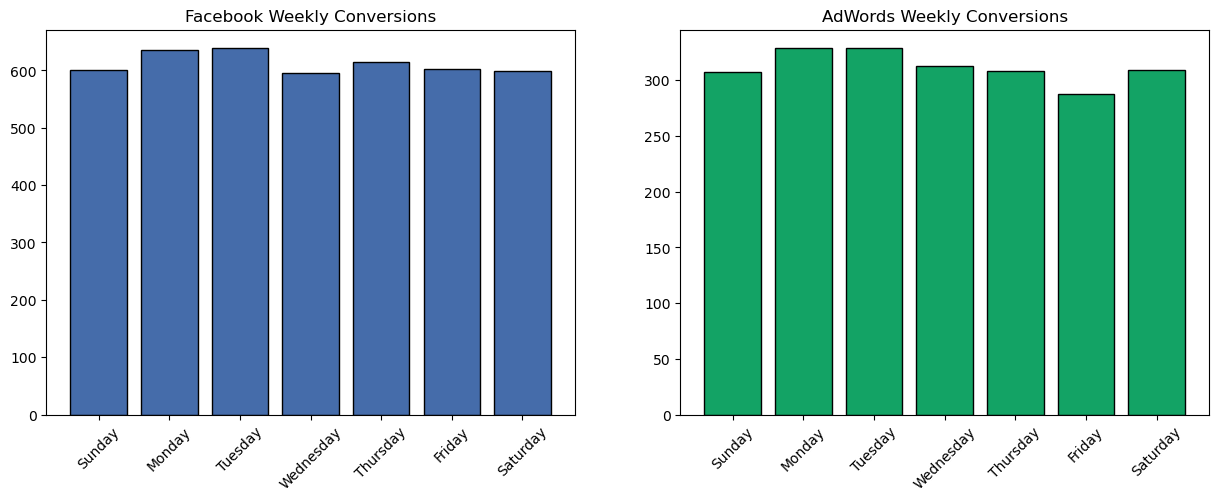

In [4]:
# visualizing the distribution of number of conversions across the days of the week for both platforms

week_days= ['Sunday','Monday','Tuesday','Wednesday','Thursday','Friday','Saturday']

plt.figure(figsize=(15,5))
plt.subplot(1,2,1)
plt.title('Facebook Weekly Conversions')
weekly_conversion = data.groupby('week_day')[['facebook_ad_conversions']].sum()
plt.bar(week_days, weekly_conversion['facebook_ad_conversions'], color = '#456caa', edgecolor = 'k')
plt.xticks(rotation=45) 


plt.subplot(1,2,2)
plt.title('AdWords Weekly Conversions')
weekly_conversion = data.groupby('week_day')[['adwords_ad_conversions']].sum()
plt.bar(week_days, weekly_conversion['adwords_ad_conversions'], color = '#13a365', edgecolor = 'k')
plt.xticks(rotation=45) 

plt.show()

**Across the days of the week, the number of conversions for campaigns on both platforms is quite uniform, with slighhtly higher conversions happening on mondays and tuesdays. However, as already seen Facebook has a significantly large number of conversions happening than AdWords.**

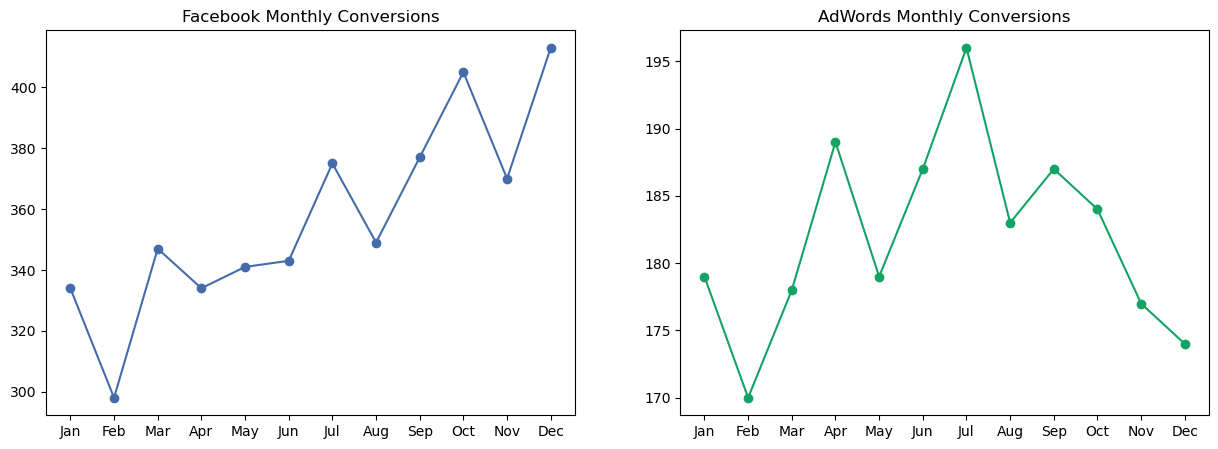

In [5]:
# visualizing the number of conversions for both platforms on a monthly basis

month_names = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']

plt.figure(figsize=(15,5))
plt.subplot(1,2,1)
plt.title('Facebook Monthly Conversions')
monthly_fb_conversion = data.groupby('month')[['facebook_ad_conversions']].sum()
plt.plot(month_names, monthly_fb_conversion['facebook_ad_conversions'],'-o', color = '#456caa')

plt.subplot(1,2,2)
plt.title('AdWords Monthly Conversions')
monthly_adwords_conversion = data.groupby('month')[['adwords_ad_conversions']].sum()
plt.plot(month_names, monthly_adwords_conversion['adwords_ad_conversions'],'-o', color = '#13a365')
plt.show()

- **Facebook has an overall upward trend for the number of conversions as the months go by. February was the month with the lowest number of conversions and december with the highest. February, April, May, June, August, and November experience a decline in conversions compared to neighboring months. These periods of decreased conversion rates could be influenced by factors such as seasonal fluctuations, changes in consumer behavior, or adjustments in marketing strategies.**
- **AdWords campaign shows a low point in number of conversions in february, similar to what was seen for facebook. This is something that can be inspected to identify what could have caused it. AdWords had another decrease in conversions in May and August. Then it went down again in October and didn't recover from it.**

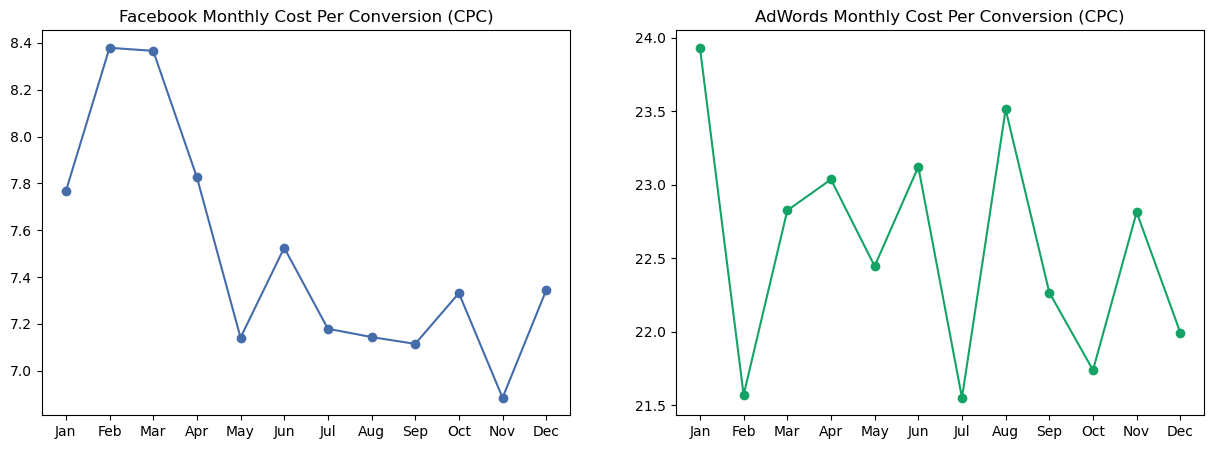

In [6]:
plt.figure(figsize=(15,5))
plt.subplot(1,2,1)
plt.title('Facebook Monthly Cost Per Conversion (CPC)')
monthly_fb_df = data.groupby('month')[['facebook_ad_conversions','cost_per_facebook_ad']].sum()
monthly_fb_df['cost_per_conversion'] = monthly_fb_df['cost_per_facebook_ad']/monthly_fb_df['facebook_ad_conversions']
plt.plot(month_names, monthly_fb_df['cost_per_conversion'],'-o', color = '#456caa')

plt.subplot(1,2,2)
plt.title('AdWords Monthly Cost Per Conversion (CPC)')
monthly_adwords_df = data.groupby('month')[['adwords_ad_conversions','cost_per_adwords_ad']].sum()
monthly_adwords_df['cost_per_conversion'] = monthly_adwords_df['cost_per_adwords_ad']/monthly_adwords_df['adwords_ad_conversions']
plt.plot(month_names, monthly_adwords_df['cost_per_conversion'],'-o', color = '#13a365')
plt.show()

- **Facebook has almost 3 times lower Cost per Conversion (CPC) range than AdWords.**
- **Facebook saw the highest CPC in February, follwoed by March and the lowest in November. The overall trend for CPC across the months for the Facebook campaign is a decreasing one.**
- **AdWords on the other hand had the lowest CPC in February and July and the highest in january. There is no significant trend in AdWords's CPC across months and it fluctuates a lot, though not by a lot of counts**